In [1]:
import sys
sys.path.append('../python-pipeline/')
sys.path.append('../snn/')
from modules import *
from wavelets import *
from har_snn import *

import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.integrate as integrate
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import seaborn as sn

import argparse
import tqdm

In [2]:
subjID = 1
sampleFreq = 64
useGravity = False

In [3]:
if useGravity:
    P = np.load('/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/pid.npy')
    X = np.load('/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/X.npy')
    Y = np.load('/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/Y.npy')
    _, P = np.unique(P, return_inverse=True)
    P, X, Y = P[P==subjID], X[P==subjID].reshape(-1,3), Y[P==subjID].repeat(300)
    time = pd.to_datetime(np.arange(len(X)) / 30.0, unit='s').set_names('time')
    data = pd.DataFrame(data=np.concatenate([X,Y[:,None]],1), index=time, 
                        columns=['x','y','z','annotation']).astype({'x':'f4', 'y':'f4', 'z':'f4', 'annotation':'string'})
    data = data.resample(f'{1000 / sampleFreq}ms').nearest() # Resample to sampleFreq
else:
    data_path = f'/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/data/realworld_gr/P{subjID:03d}.csv.gz'
    data = pd.read_csv(data_path, index_col='time', parse_dates=['time'],
                       dtype={'x': 'f4', 'y': 'f4', 'z': 'f4', 'annotation': 'string'})
    data = data.resample(f'{1000 / sampleFreq}ms').nearest() # Resample to sampleFreq

data[['x','y','z']] = data[['x','y','z']].interpolate()
# data['annotation'] = data['annotation'].ffill()
data.reset_index(inplace=True)
data.time = data.time.apply(lambda x: x.timestamp())
data.time = data.time - data.time[0]

Text(0.5, 0, 'Time [s]')

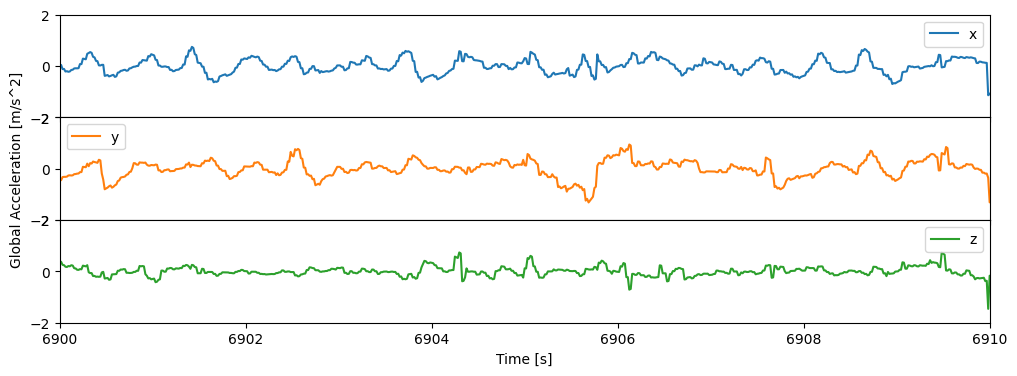

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(12,4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0)

ax[0].plot(data.time, data.x, color=f'C0', label='x')
ax[1].plot(data.time, data.y, color=f'C1', label='y')
ax[2].plot(data.time, data.z, color=f'C2', label='z')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[0].set_xlim(6900, 6910)
ax[0].set_ylim(-2, 2)
ax[1].set_ylabel('Global Acceleration [m/s^2]')
ax[2].set_xlabel('Time [s]')

In [19]:
from rockpool.devices.xylo.syns63300 import IMUIFSim
from rockpool.devices.xylo.syns63300.imuif import FilterBank
from rockpool.devices.xylo.syns63300 import Quantizer

input_data = data[['x','y','z']].to_numpy()
input_data = np.clip(input_data / 2, -1+1e-5, 1-1e-5)
quantizer = Quantizer(shape=3, num_bits=16)
Q_data, _, _ = quantizer(input_data)

# Using default values for frequency bands
frequencies = [sampleFreq / 200 * np.sqrt(fi * fj)
               for fi, fj in [(1,2),(2,4),(4,8),(8,16),(16,32)]]
mod = IMUIFSim(bypass_jsvd=True, sampling_freq=sampleFreq, select_iaf_output=True, iaf_threshold_values=4098)
# mod = FilterBank()

try: spikes , _, r_d = mod(Q_data, record = True)
except ValueError: sys.exit()

outLabels = [f'spikes_{d}_{1/frequencies[j]:.2f}' for d in 'xyz' for j in range(5)]
data[outLabels] = spikes.reshape(-1, 3 * 5).astype(bool)

Text(0.5, 0, 'Time [s]')

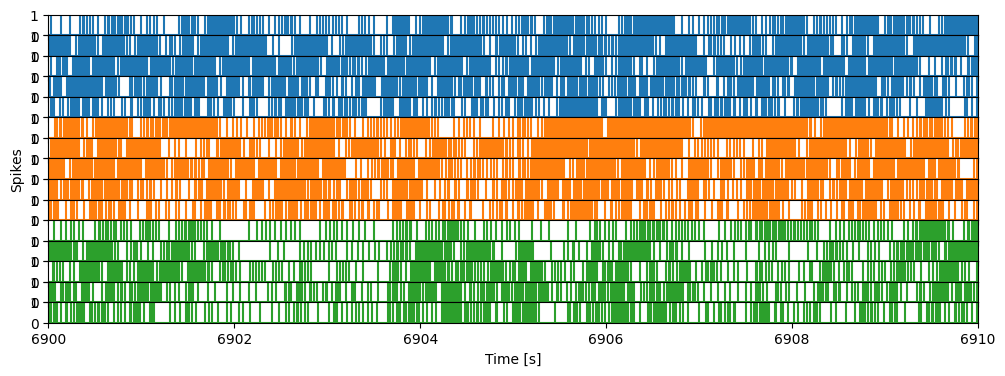

In [110]:
fig, ax = plt.subplots(15, 1, figsize=(12,4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0)

axit = iter(ax)
for di, d in enumerate('xyz'):
    for fi, f in enumerate(frequencies):
        axi = next(axit)
        x = data.time[(data.time>=6900)*(data.time<=6910)].to_numpy()
        y = data[f'spikes_{d}_{1/f:.2f}'][(data.time>=6900)*(data.time<=6910)].to_numpy()
        
        # axi.plot(x, y, color=f'C{di}', label=d)
        axi.stem(x, y, linefmt=f'C{di}', markerfmt='', basefmt=f'C{di}', label=d)
        # axi.scatter(x[y!=0], y[y!=0], s=10*np.abs(y[y!=0]), c=f'C{di}')
        # axi.scatter(x, np.zeros_like(x), s=10, c=f'C{di}', marker='|')
        
        # if fi == 0: axi.legend()

ax[0].set_xlim(6900, 6910)
ax[0].set_ylim(0, 1)
ax[7].set_ylabel('Spikes')
ax[14].set_xlabel('Time [s]')

In [23]:
from rockpool.devices.xylo.syns63300 import IMUIFSim
from rockpool.devices.xylo.syns63300.imuif import FilterBank
from rockpool.devices.xylo.syns63300 import Quantizer

rec_data, _, r_d = mod.model[0](Q_data, record = True)
rec_data = rec_data[0].astype(int).T.reshape(3,5,-1).sum(1).T / 2 ** 15
spikes , _, r_d = mod(Q_data, record = True)

Text(0.5, 0, 'Time [s]')

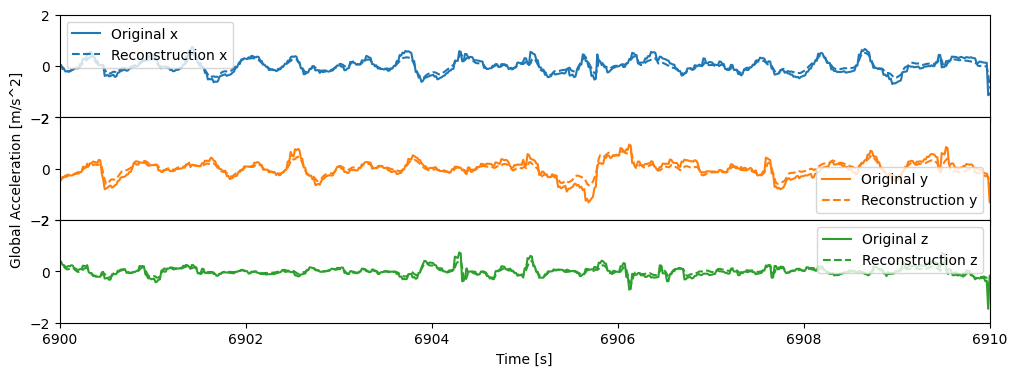

In [25]:
fig, ax = plt.subplots(3, 1, figsize=(12,4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0)

ax[0].plot(data.time, data.x, color=f'C0', label='Original x')
ax[1].plot(data.time, data.y, color=f'C1', label='Original y')
ax[2].plot(data.time, data.z, color=f'C2', label='Original z')
ax[0].plot(data.time, rec_data.T[0], '--', color=f'C0', label='Reconstruction x')
ax[1].plot(data.time, rec_data.T[1], '--', color=f'C1', label='Reconstruction y')
ax[2].plot(data.time, rec_data.T[2], '--', color=f'C2', label='Reconstruction z')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[0].set_xlim(6900, 6910)
ax[0].set_ylim(-2, 2)
ax[1].set_ylabel('Global Acceleration [m/s^2]')
ax[2].set_xlabel('Time [s]')

In [24]:
rec_data.shape

(531198, 3)

In [5]:
# Set parameters for the IMU pipeline
globalFrame = True
usePower = False
waveletFunc = powerWavelet if usePower else accelerationWavelet
frequencies = torch.tensor([0.5, 1.0, 2.0, 4.0, 8.0])
singleDim = False
dim = 1 if singleDim else 3
numFilt = len(frequencies)

In [6]:
# Initialize modules
waveletFilter = WaveletIIRFilterModule(
    sampleFreq,
    singleDim=singleDim,
    frequencies=frequencies,
    waveletFunc=waveletFunc
)

maxFilter = MaxFilterModule(
    sampleFreq,
    usePower=usePower,
    singleDim=singleDim,
    frequencies=frequencies,
    maxFiltWin=(0.3, 0.0)
)

nimup = nn.Sequential(
    # localToGlobal,
    # accelToPower,
    waveletFilter,
    maxFilter,
)

In [7]:
# Forward pass data
out = []
for t, row in tqdm.tqdm(data.iterrows(), total=len(data)):
    inp = row[['x','y','z']].to_numpy(dtype=float)
    res = nimup(torch.Tensor(inp))
    out += [res.numpy()]

outLabels = [f'events_{d}_{1/frequencies[j]:.2f}'
             for d in ('xyz' if dim == 3 else '_') for j in range(numFilt)]
data[outLabels] = np.stack(out, 0).reshape(-1, dim * numFilt)

100%|██████████| 531198/531198 [03:49<00:00, 2313.22it/s]


Text(0.5, 0, 'Time [s]')

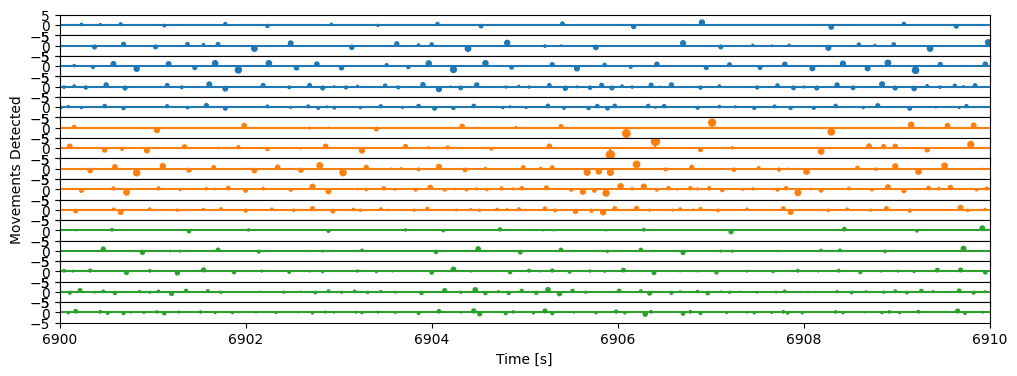

In [85]:
fig, ax = plt.subplots(15, 1, figsize=(12,4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0)

axit = iter(ax)
for di, d in enumerate('xyz'):
    for fi, f in enumerate(frequencies):
        axi = next(axit)
        x = data.time[(data.time>=6900)*(data.time<=6910)].to_numpy()
        y = data[f'events_{d}_{1/f:.2f}'][(data.time>=6900)*(data.time<=6910)].to_numpy()
        
        # T = len(y)
        # Tnew = int(T / 4)
        # spikes_cum = np.cumsum(y, axis=0)
        # spikes_cum_f = interp1d(np.arange(T), spikes_cum,
        #                         kind='nearest', axis=0, fill_value='extrapolate')
        # spikes_cum_down = spikes_cum_f(np.linspace(0, T, Tnew, endpoint=False))
        # spikes_down = np.diff(spikes_cum_down, axis=0, prepend=0)
        # x, y = spikes_down
        
        # axi.plot(x, y, color=f'C{di}', label=d)
        axi.stem(x, y, linefmt=f'C{di}', markerfmt='', basefmt=f'C{di}', label=d)
        axi.scatter(x[y!=0], y[y!=0], s=10*np.abs(y[y!=0]), c=f'C{di}')
        # axi.scatter(x, np.zeros_like(x), s=4, c=f'C{di}', marker='|')
        
        # if fi == 0: axi.legend()

ax[0].set_xlim(6900, 6910)
ax[0].set_ylim(-5, 5)
ax[7].set_ylabel('Movements Detected')
ax[14].set_xlabel('Time [s]')

In [14]:
maxS = int((sampleFreq / frequencies).max())
maxM = int(np.min([2 * maxS, len(data)]))
delayMaxFilter = nimup.get_submodule('1.maxPooler').kernel_size[1]
for d in 'xyz':
    data[f'rec_{d}'] = 0.0
    for j in range(numFilt):
        si = sampleFreq / frequencies[j]
        M = np.min([2 * si, len(data)]).astype(int)
        impulse = signal.unit_impulse(maxM + delayMaxFilter, maxM // 2 - int(si) // 2)
        # nimup.get_submodule('model.2').filterBank.shape[0] // 2
        wavelet = signal.convolve(impulse, waveletFunc(si, si).flip(0), 'same')
        data[f'rec_{d}'] += signal.convolve(data[f'events_{d}_{1/frequencies[j]:.2f}'],
                                                     wavelet, 'same') / 2.5
        # plt.plot(wavelet)
    # dataFrameLeft[f'rec_{d}'] = integrate.cumulative_trapezoid(dataFrameLeft[f'rec_{d}'], dataFrameLeft['time'], initial=0)
    # dataFrameLeft[f'rec_{d}'] = np.sqrt(2 * np.abs(dataFrameLeft[f'rec_{d}']))
    # dataFrameLeft[f'rec_{d}'] = np.gradient(dataFrameLeft[f'rec_{d}'], dataFrameLeft['time']) 
    # dataFrameLeft[f'rec_{d}'] = signal.filtfilt(b, a, dataFrameLeft[f'rec_{d}'])

delaySamples = maxS // 2 + delayMaxFilter // 2

Text(0.5, 0, 'Time [s]')

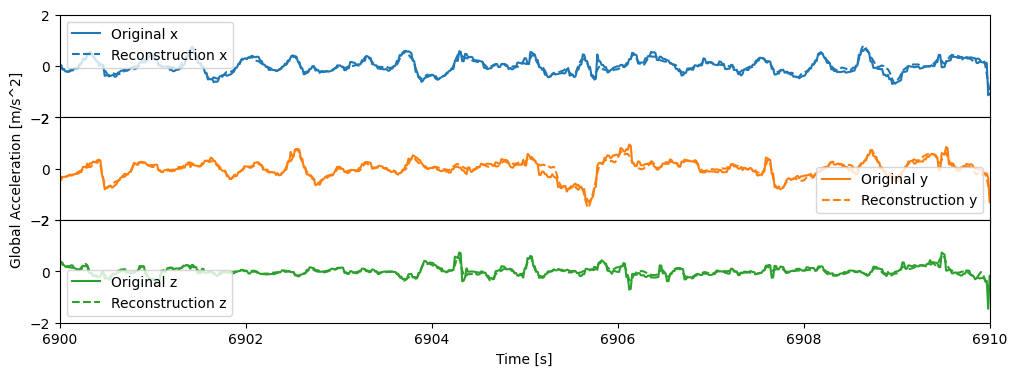

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(12,4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0)

ax[0].plot(data.time, data.x, color=f'C0', label='Original x')
ax[1].plot(data.time, data.y, color=f'C1', label='Original y')
ax[2].plot(data.time, data.z, color=f'C2', label='Original z')
ax[0].plot(data.time, data.rec_x, '--', color=f'C0', label='Reconstruction x')
ax[1].plot(data.time, data.rec_y, '--', color=f'C1', label='Reconstruction y')
ax[2].plot(data.time, data.rec_z, '--', color=f'C2', label='Reconstruction z')

ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[0].set_xlim(6900, 6910)
ax[0].set_ylim(-2, 2)
ax[1].set_ylabel('Global Acceleration [m/s^2]')
ax[2].set_xlabel('Time [s]')

In [5]:
# Get time
time = data['time'].to_numpy()
fs = int(1 / np.diff(time).mean()) # sampling frequency
dt = 1 / fs # sampling period

# Get acceleration and band-pass filter
acceleration = data[[f'{ax}' for ax in 'xyz']].to_numpy()
b, a = signal.butter(3, (0.1, 10), btype='bandpass', fs=fs)
acceleration = signal.filtfilt(b, a, acceleration, axis=0)

# Get velocity and band-pass filter
velocity = integrate.cumulative_trapezoid(acceleration, dx=dt, axis=0, initial=0)
b, a = signal.butter(3, (0.1, 10), btype='bandpass', fs=1/dt)
velocity = signal.filtfilt(b, a, velocity, axis=0)

# Get position and band-pass filter
position = integrate.cumulative_trapezoid(velocity, dx=dt, axis=0, initial=0)
b, a = signal.butter(3, (0.1, 10), btype='bandpass', fs=1/dt)
position = signal.filtfilt(b, a, position, axis=0)

# Get power and band-pass filter
power = acceleration * velocity
b, a = signal.butter(3, (0.1, 10), btype='bandpass', fs=fs)
power = signal.filtfilt(b, a, power, axis=0)

# Get total power along XYZ
power_total = power.sum(1)

In [6]:
# Trim data to focus on 100-150 seconds
mask_time = (time >= 6800) * (time < 7000)
time = time[mask_time]
acceleration = acceleration[mask_time]
velocity = velocity[mask_time]
position = position[mask_time]
power = power[mask_time]
power_total = power_total[mask_time]

In [7]:
# Define acceleration wavelet
def accelerationWavelet(M: int, s: float):
    '''Wavelet corresponding to acceleration in a primitive movement

    :param M: length (in samples) of the wavelet
    :param s: width (in samples) of the wavelet
    '''
    x = (np.arange(M) - (M - 1) / 2) / s
    wavelet = (x > -0.5) * (x < 0.5) * 29 / 4 * x * (4 * x ** 2 - 1)
    output = np.sqrt(1 / s) * wavelet
    return output

# Define power wavelet
def powerWavelet(M: int, s: float):
    '''Wavelet corresponding to power (dE/dt) in a primitive movement

    :param M: length (in samples) of the wavelet
    :param s: width (in samples) of the wavelet
    '''
    x = (np.arange(M) - (M - 1) / 2) / s
    wavelet = (x > -0.5) * (x < 0.5) * 40 / 3 * x * (4 * x ** 2 - 1) ** 3
    output = np.sqrt(1 / s) * wavelet
    return output

In [8]:
# Define widths range to compute wavelet transform
wmin, wmax = 0.02, 5 # in seconds

# Define widths to compute wavelet transform
widths = np.logspace(np.log10(wmin), np.log10(wmax), 101, base=10) # in seconds
widths_samples = widths / dt # in samples

# Get resolution of widths
dw = np.diff(np.log10(widths)).mean() # in decades

In [9]:
# Compute wavelet transform for acceleration in each axis, and then aggregate them with norm
wavelet_accel = np.stack([signal.cwt(ai, accelerationWavelet, widths_samples) for ai in acceleration.T], axis=2)
# wavelet_accel = np.linalg.norm(wavelet_accel, axis=2)

# Compute wavelet transform for power
wavelet_power = signal.cwt(power_total, powerWavelet, widths_samples)

/tmp/ipykernel_3941470/1778204356.py:2: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  wavelet_accel = np.stack([signal.cwt(ai, accelerationWavelet, widths_samples) for ai in acceleration.T], axis=2)
/tmp/ipykernel_3941470/1778204356.py:6: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  wavelet_power = signal.cwt(power_total, powerWavelet, widths_samples)


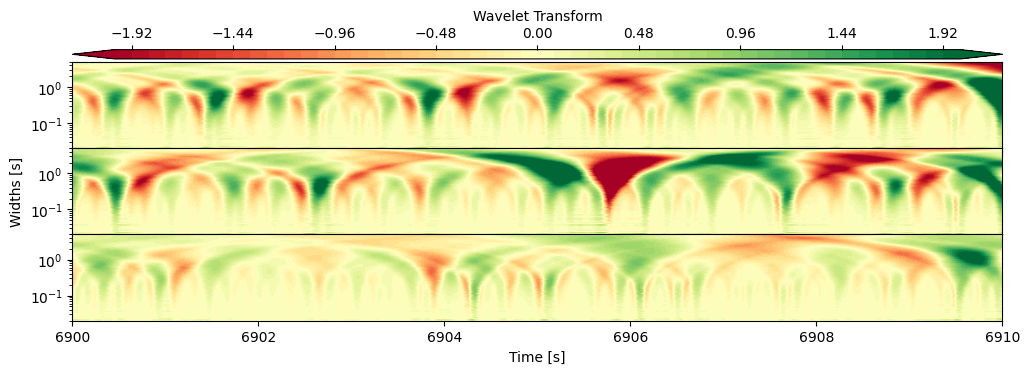

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(12,4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0)

v_accel = 2 # max(np.abs(np.quantile(wavelet_accel, (0.005, 0.995))))

qd_accel = ax[0].contourf(time, widths, wavelet_accel[...,0], vmin=-v_accel, vmax=v_accel,
                          levels=np.linspace(-v_accel, v_accel, 51), cmap='RdYlGn', extend='both')
qd_accel = ax[1].contourf(time, widths, wavelet_accel[...,1], vmin=-v_accel, vmax=v_accel,
                          levels=np.linspace(-v_accel, v_accel, 51), cmap='RdYlGn', extend='both')
qd_accel = ax[2].contourf(time, widths, wavelet_accel[...,2], vmin=-v_accel, vmax=v_accel,
                          levels=np.linspace(-v_accel, v_accel, 51), cmap='RdYlGn', extend='both')

cbar_accel = plt.colorbar(qd_accel, ax=ax, location='top', aspect=100, pad=0.01, label='Wavelet Transform')

ax[0].set_xlim(6900,6910)
ax[1].set_ylabel('Widths [s]')
ax[2].set_xlabel('Time [s]')
ax[0].set_yscale('log')

In [20]:
# Define window hyperparameters to obtain local maxima
win_height = int(0.5 / dw) # numerator in decades
win_width = int(0.3 / dt) # numerator in seconds

# Define threshold hyperparameters to obtain local maxima
threshold_accel = .5
threshold_power = .2

# Define range of widths hyperparameters to obtain local maxima
width_min = 0.1
width_max = 2

In [21]:
# Extract local maxima from acceleration
maxima_accel0 = np.nonzero((ndimage.maximum_filter(wavelet_accel[...,0], size=(win_height, win_width)) == wavelet_accel[...,0]) *
                          (wavelet_accel[...,0] > threshold_accel) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 
maxima_accel1 = np.nonzero((ndimage.maximum_filter(wavelet_accel[...,1], size=(win_height, win_width)) == wavelet_accel[...,1]) *
                          (wavelet_accel[...,1] > threshold_accel) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 
maxima_accel2 = np.nonzero((ndimage.maximum_filter(wavelet_accel[...,2], size=(win_height, win_width)) == wavelet_accel[...,2]) *
                          (wavelet_accel[...,2] > threshold_accel) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 
minima_accel0 = np.nonzero((ndimage.maximum_filter(-wavelet_accel[...,0], size=(win_height, win_width)) == -wavelet_accel[...,0]) *
                          (wavelet_accel[...,0] < -threshold_accel) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 
minima_accel1 = np.nonzero((ndimage.maximum_filter(-wavelet_accel[...,1], size=(win_height, win_width)) == -wavelet_accel[...,1]) *
                          (wavelet_accel[...,1] < -threshold_accel) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 
minima_accel2 = np.nonzero((ndimage.maximum_filter(-wavelet_accel[...,2], size=(win_height, win_width)) == -wavelet_accel[...,2]) *
                          (wavelet_accel[...,2] < -threshold_accel) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 

# Extract local maxima from power
maxima_power = np.nonzero((ndimage.maximum_filter(wavelet_power, size=(win_height, win_width)) == wavelet_power) *
                          (wavelet_power > threshold_power) * # Filter out small maxima
                          ((widths > width_min) * (widths < width_max))[:,None]) # Filter out widths outside interval of interest 

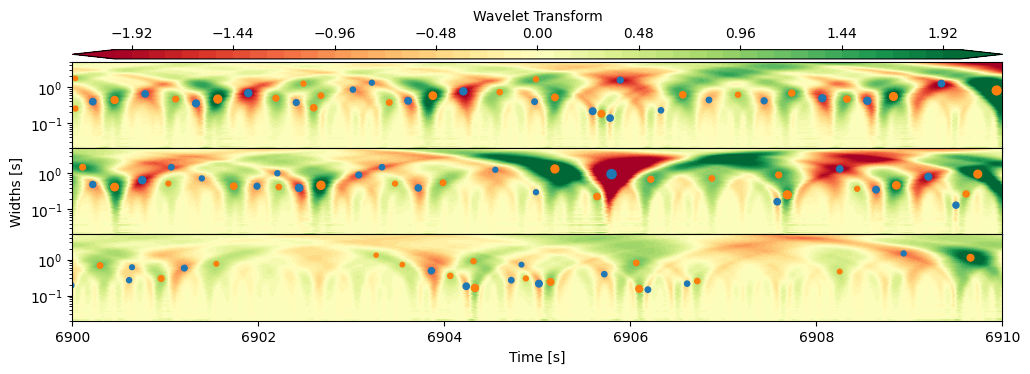

In [24]:
fig, ax = plt.subplots(3, 1, figsize=(12,4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0)

v_accel = 2 # max(np.abs(np.quantile(wavelet_accel, (0.005, 0.995))))

qd_accel = ax[0].contourf(time, widths, wavelet_accel[...,0], vmin=-v_accel, vmax=v_accel,
                          levels=np.linspace(-v_accel, v_accel, 51), cmap='RdYlGn', extend='both')
qd_accel = ax[1].contourf(time, widths, wavelet_accel[...,1], vmin=-v_accel, vmax=v_accel,
                          levels=np.linspace(-v_accel, v_accel, 51), cmap='RdYlGn', extend='both')
qd_accel = ax[2].contourf(time, widths, wavelet_accel[...,2], vmin=-v_accel, vmax=v_accel,
                          levels=np.linspace(-v_accel, v_accel, 51), cmap='RdYlGn', extend='both')

ax[0].scatter(time[maxima_accel0[1]], widths[maxima_accel0[0]],
              s=5+8*(wavelet_accel[...,0][maxima_accel0] / np.sqrt(widths[maxima_accel0[0]])), color='C1')
ax[1].scatter(time[maxima_accel1[1]], widths[maxima_accel1[0]],
              s=5+8*(wavelet_accel[...,1][maxima_accel1] / np.sqrt(widths[maxima_accel1[0]])), color='C1')
ax[2].scatter(time[maxima_accel2[1]], widths[maxima_accel2[0]],
              s=5+8*(wavelet_accel[...,2][maxima_accel2] / np.sqrt(widths[maxima_accel2[0]])), color='C1')

ax[0].scatter(time[minima_accel0[1]], widths[minima_accel0[0]],
              s=5-8*(wavelet_accel[...,0][minima_accel0] / np.sqrt(widths[minima_accel0[0]])), color='C0')
ax[1].scatter(time[minima_accel1[1]], widths[minima_accel1[0]],
              s=5-8*(wavelet_accel[...,1][minima_accel1] / np.sqrt(widths[minima_accel1[0]])), color='C0')
ax[2].scatter(time[minima_accel2[1]], widths[minima_accel2[0]],
              s=5-8*(wavelet_accel[...,2][minima_accel2] / np.sqrt(widths[minima_accel2[0]])), color='C0')

cbar_accel = plt.colorbar(qd_accel, ax=ax, location='top', aspect=100, pad=0.01, label='Wavelet Transform')

ax[0].set_xlim(6900,6910)
ax[1].set_ylabel('Widths [s]')
ax[2].set_xlabel('Time [s]')
ax[0].set_yscale('log')